# 2026年度 IoPサマースクール #9 演習2

気象衛星「ひまわり」の観測データ（2025年8月分）を使用し、  
**日射量を予測する機械学習モデル**を構築します。


In [ ]:
# 使用するライブラリを読み込み
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from tensorflow.keras import Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    Concatenate, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [ ]:
# ひまわりデータ2025年8月分のダウンロード
!git clone https://github.com/ikunao/260909_SS9
!unzip ./260909_SS9/himawari.zip -d /content/


In [ ]:
# ひまわりデータの読み込み
path_b03 = '/content/b03_japan/*.jpg'
x1 = []

for p in sorted(glob.glob(path_b03)):
    image = Image.open(p).convert('L')
    x1.append(np.array(image))

x1 = np.array(x1).astype(np.uint8)
print(x1.shape)

In [ ]:
# ひまわりデータの確認
fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(x1[0], cmap='gray', vmin=0, vmax=100)

def update(frame):
    im.set_data(x1[frame])
    return [im]

ani = FuncAnimation(fig, update, frames=48, interval=100)
HTML(ani.to_jshtml())


# 問題　日本時間8月25日正午の四国の画像を表示してください。


In [ ]:
plt.imshow()

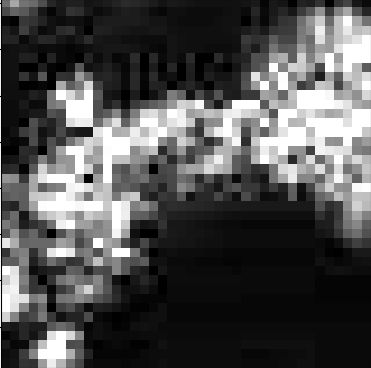

In [ ]:
#雲の移動量可視化（オプティカルフロー法）

img1 = x1[0].astype(np.uint8)
img2 = x1[5].astype(np.uint8)

dis = cv2.DISOpticalFlow_create(cv2.DISOPTICAL_FLOW_PRESET_FAST)
flow = dis.calc(img1, img2, None)

mask = img1 > 10
ys, xs = np.where(mask)
idx = np.random.choice(len(xs), 500, replace=False)

plt.figure(figsize=(12, 6))
plt.imshow(img2, cmap='gray', vmin=0, vmax=100)
cmap = plt.get_cmap("jet")

for x, y in zip(xs[idx], ys[idx]):
    dx, dy = flow[y, x]
    color = cmap((dx*dx + dy*dy)*0.002)
    plt.arrow(
        x, y, dx, dy, color=color, linewidth=2, head_width=2
    )


In [ ]:
# 高知気象台環境情報データをデータフレーム格納

df = pd.read_csv(
    '/content/kisho_kochi.csv',
    encoding='shift_jis',
    parse_dates=['年月日時'],
    index_col='年月日時'
)

# 環境情報の確認
print(df[:20])

In [ ]:
# 晴天時日射量と実際の日射量の相関

R2 = r2_score(df["日射量"], df["晴天時日射量"])

plt.scatter(df["晴天時日射量"], df["日射量"],label=f'R²={R2:.3f}')
plt.xlabel('cloudless')
plt.ylabel('Actual')
plt.legend()
plt.show()


# 問題　以下の学習コードを適宜変更し、最も精度がよくなった（R2が大きい）場合の条件とR2の値を報告してください。

In [ ]:
#学習データ作成

#説明変数（衛星画像）
X_img = np.array(x1).astype(np.uint8)
X_img = (X_img - np.mean(X_img)) / (np.max(X_img) - np.min(X_img))

X_img = X_img[0:360]                #最初の360枚（24*15日分）を抽出
X_img = X_img[:,::5, ::10]          #画素を間引いて縮小(400x200→40x40)。大きくすると学習に時間がかかるため注意。

#説明変数（スカラー）
x11 = np.array(df["晴天時日射量"], dtype=np.float32)
x12 = np.array(df["気温"], dtype=np.float32)
x13 = np.array(df["相対湿度"], dtype=np.float32)
x14 = np.array(df["降水量"], dtype=np.float32)
x15 = np.array(df["現地気圧"], dtype=np.float32)

X_scalar = np.stack([x11, x12], axis=1)
X_scalar = X_scalar[0:360]
mean = np.nanmean(X_scalar, axis=0)
minv = np.nanmin(X_scalar, axis=0)
maxv = np.nanmax(X_scalar, axis=0)
X_scalar = (X_scalar - mean) / (maxv - minv)

#目的変数
y = np.array(df["日射量"], dtype=np.float32)
y = y[0:360]

# 学習データと検証データに分離（前66% → train、後33% → val）
split_idx = int(len(X_img) * 0.66)
X_img_train, X_img_val = X_img[:split_idx], X_img[split_idx:]
X_scalar_train, X_scalar_val = X_scalar[:split_idx], X_scalar[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

In [ ]:
# 画像特徴と数値情報を融合した軽量CNN回帰ネットワーク

# 画像の畳み込み
image_input = Input(shape=(40, 40, 1))
v = Conv2D(8, (3, 3), activation='relu', padding='same', dilation_rate=3)(image_input)
v = MaxPooling2D((2, 2))(v)
v = Conv2D(8, (3, 3), activation='relu', padding='same', dilation_rate=3)(v)
v = GlobalAveragePooling2D()(v)
v = Dense(8, activation='relu')(v)

# 数値データのNN
meta_input = Input(shape=(2,))    #インプットデータのshapeに合わせる
m = Dense(8, activation='relu')(meta_input)
m = Dense(8, activation='relu')(m)

# 画像と数値を結合
combined = Concatenate()([v, m])
output = Dense(1, activation='linear')(combined)

# モデル構築
model = Model(inputs=[image_input, meta_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')


In [ ]:
# モデル学習
history = model.fit(
    [X_img_train, X_scalar_train], y_train,
    validation_data=([X_img_val, X_scalar_val], y_val),
    epochs=10,
    batch_size=8
)

# 学習曲線
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [ ]:
# 予測結果
y_pred = model.predict([X_img_val, X_scalar_val]).flatten()

reg_model = LinearRegression()
reg_model.fit(y_val.reshape(-1, 1), y_pred)
reg_line = reg_model.predict(y_val.reshape(-1, 1))
R2 = np.corrcoef(y_val, y_pred)[0, 1]

plt.scatter(x=y_val, y=y_pred, color='blue', label='Predicted vs True')
plt.plot(y_val, reg_line, color='red', label=f'Regression Line (R={R2:.3f})')
plt.xlabel('True PPFD')
plt.ylabel('Predicted PPFD')
plt.legend()
plt.show()

In [ ]:
# 時系列結果の表示（学習に使用しなかった後半）
y_pred = model.predict([X_img_val ,X_scalar_val]).flatten()
time_index = np.arange(len(y_val))

# グラフの描画
plt.figure(figsize=(10, 4))
plt.plot(time_index, y_val, label='True', color='blue', linewidth=2)
plt.plot(time_index, y_pred, label='Predicted', color='orange', linewidth=2)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()